In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


df=pd.read_csv('../data/diabetes.csv')
df.head()
#df.shape


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df.isnull().sum()

df.info()

df.value_counts('Outcome')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Outcome
0    500
1    268
Name: count, dtype: int64

*Dataset is moderately unbalanced, 65% of the samples belong to non-diabetic class (0) while the rest belong to diabetic class(1)*

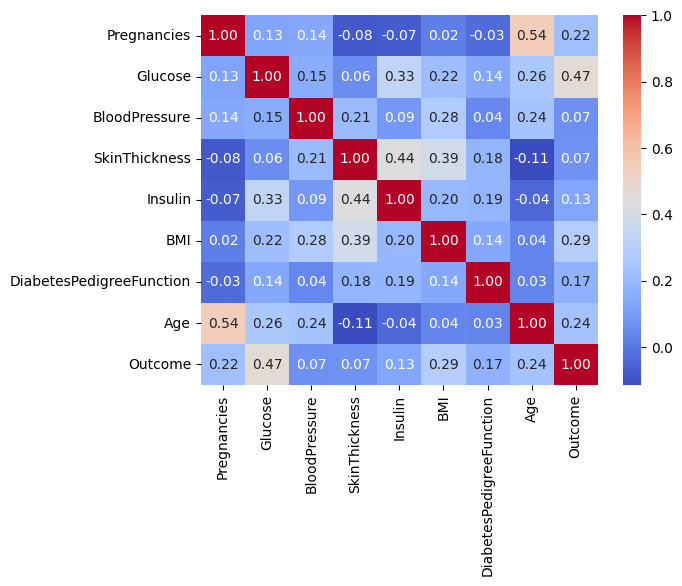

<Figure size 1600x1200 with 0 Axes>

In [12]:
sns.heatmap(df.corr(), annot=True,fmt=".2f",        # 2 decimal places
    cmap="coolwarm",
    annot_kws={"size":10})
plt.figure(figsize=(16,12))
plt.show()

*Glucose shows highest positive corelation with the outcome, then BMI and age have highest corelation.*

In [16]:
X=df.drop('Outcome',axis=1)
Y=df['Outcome']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test) 

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled,Y_train)
predictions=model.predict(X_test_scaled)

In [17]:
print("Accuracy:", accuracy_score(Y_test, predictions))
print("Precision:", precision_score(Y_test, predictions))
print("Recall:", recall_score(Y_test, predictions))
print("F1 Score:", f1_score(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))

Accuracy: 0.7337662337662337
Precision: 0.6031746031746031
Recall: 0.7037037037037037
F1 Score: 0.6495726495726496
Confusion Matrix:
 [[75 25]
 [16 38]]


In [20]:
joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

*Logistic Regression achieved 73% accuracy with a recall of 70% on the positive class. Given the medical context, recall is prioritized to minimize false negatives.*